In [1]:
import numpy as np

from modelVelocity import ModelVelocity
from logProb import log_prob
from MCMC import MCMC
from readData import ReadData

import os
os.environ["OMP_NUM_THREADS"] = "1"

In [ ]:
#Here we need to overload the ModelVelocity with the new host model. Hence, we also need to process the parameters differently.
class ModelVelocity_2S(ModelVelocity):

    def __init__(self, data):
        super().__init__(data)

    def set_params(self, n, Mbulge, re_bulge, Mbh):

        self.n = n
        self.Mbulge = Mbulge
        self.re_bulge = re_bulge
        self.Mbh = Mbh
    
        #Get the convenience constant Ie
        g_func_rnorm_max = self.g_func.rnorm_max
        self.Ie_bulge = Mbulge/self.g_func.g_interp((n,g_func_rnorm_max))

        return

    def Mhost(self, r):

        rnorm = r/self.re_bulge
        return self.Ie_bulge * self.g_func.g_interp((self.n, rnorm))


## Initilizations

Here we first read the data file, using the [ReadData](readData.py) object. This is just for conveniency, but it is simply a function that reads and stores the relevant numbers in the file [data.dat](data.dat). 

The second step is to initialize the [ModelVelocity](modelVelocity.py) object, which holds a number of values relevant for the modeling and creates the interpolated values of the F and g functions. See the [README file](README.md) for more details. 

Finally, we set the boundaries for each of the parameters to be used during the MCMC. 

In [2]:
#Read the measurements. 
data = ReadData()

In [3]:
#Initialize the modeling object. This takes some time as some functions need to be interpolated. 
modelv = ModelVelocity(data)

In [4]:
#Set the bounds for each of the parameters we will fit. 

#SMBH Mass
log_Mbh_min  , log_Mbh_max   = 0.0 , 11.0 #Base 10 logarithm of the SMBH mass in units of Solar Masses.

#Host Galaxy Parameters
n_host_min , n_host_max      = 0.50, 10.0 #Sersic index 
Re_host_min, Re_host_max     = 0.25, 10.0 #Effective radius in kpc. 
log_Mhost_min, log_Mhost_max = 8.0 , 12.0 #Base 10 logarithm of the total host mass in units of Solar Masses.

#Put the bounds in the right format and order for the MCMC. 
params_min = np.array([n_host_min,  log_Mhost_min, Re_host_min, log_Mbh_min])
params_max = np.array([n_host_max,  log_Mhost_max, Re_host_max, log_Mbh_max])

## Case 1: Fit All Parameters

Here we allow all 4 paremeters to be fit to the data. 

In [5]:
#Initial guesses. Order is n, log Mbulge, re bulge, log Mbh.
params_init = np.array([4.0, 10.5, 1.5, 10.])

#Set which parameters are fixed. In this case, it is none, so it is just an array of False values.
ifix  = np.zeros(params_init.shape, dtype=bool)

100%|██████████| 5000/5000 [10:38<00:00,  7.83it/s]


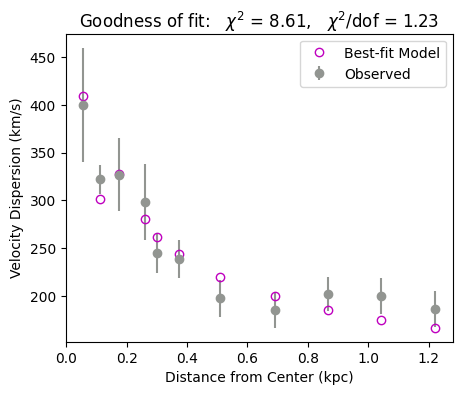

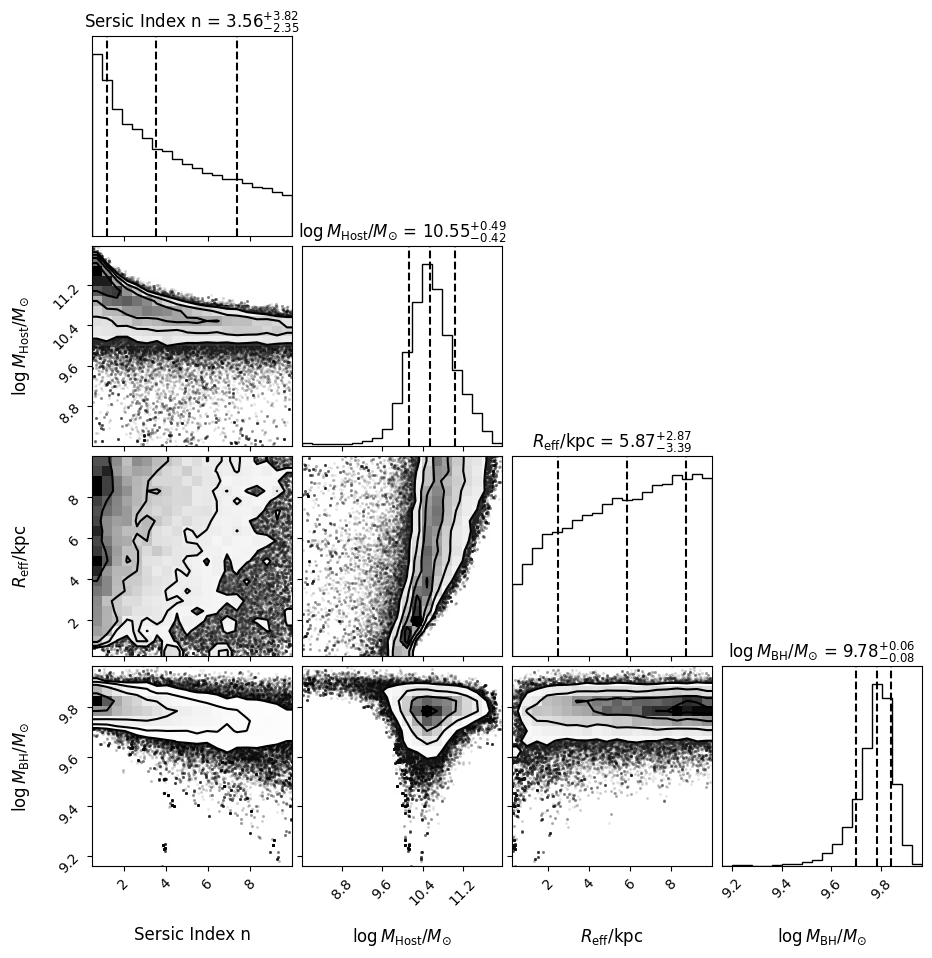

In [6]:
#####
# MCMC
#####

#Set the MCMC object, which is just a convenient wrapper for emcee. 
myMCMC = MCMC(params_init, params_min, params_max, modelv, log_prob, data.sigma_obs, data.sigma_obs_err, ifix=ifix)

#Run th MCMC
myMCMC.runMCMC()

#Save the flatchain. 
myMCMC.save_flat_samples("MCMC_flatchain.all_params.txt")
#myMCMC.load_flat_samples("MCMC_flatchain.all_params.txt")

#Plot the best-fit model compared to the data. 
myMCMC.plot_bestfit()

#Make the corner plot.
myMCMC.corner_plot()

In [8]:
10**10.55

35481338923.357605

## Case 2: Limiting the Sérsic index and Effective Radius

It is clear from the corner plot of Case 1 that we cannot constrain the Sérsic index n and the Effective radius of the host. Hence, we will fix them to those of the [CII] integrated emission, which is also consistent with the distribution of the stellar UV emission in HST images [Diaz-Santos et al. (2021)](https://ui.adsabs.harvard.edu/abs/2021A%26A...654A..37D/abstract). These are a Sérsic index of 0.5 (i.e., Gaussian) and an Effective Radius of 1.2kpc.

In [9]:
#Set the bounds for each of the parameters we will fit. 

#SMBH Mass
log_Mbh_min  , log_Mbh_max   = 0.0 , 11.0 #Base 10 logarithm of the SMBH mass in units of Solar Masses.

#Host Galaxy Parameters
n_host_min , n_host_max      = 0.50,  2.0 #Sersic index 
Re_host_min, Re_host_max     = 1.1 , 1.6 #Effective radius in kpc. 
log_Mhost_min, log_Mhost_max = 8.0 , 12.0 #Base 10 logarithm of the total host mass in units of Solar Masses.

#Put the bounds in the right format and order for the MCMC. 
params_min = np.array([n_host_min,  log_Mhost_min, Re_host_min, log_Mbh_min])
params_max = np.array([n_host_max,  log_Mhost_max, Re_host_max, log_Mbh_max])

100%|██████████| 5000/5000 [10:48<00:00,  7.72it/s]


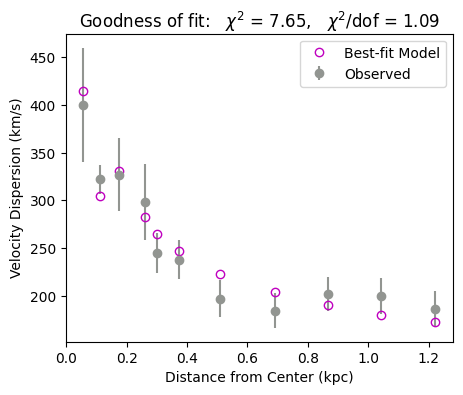

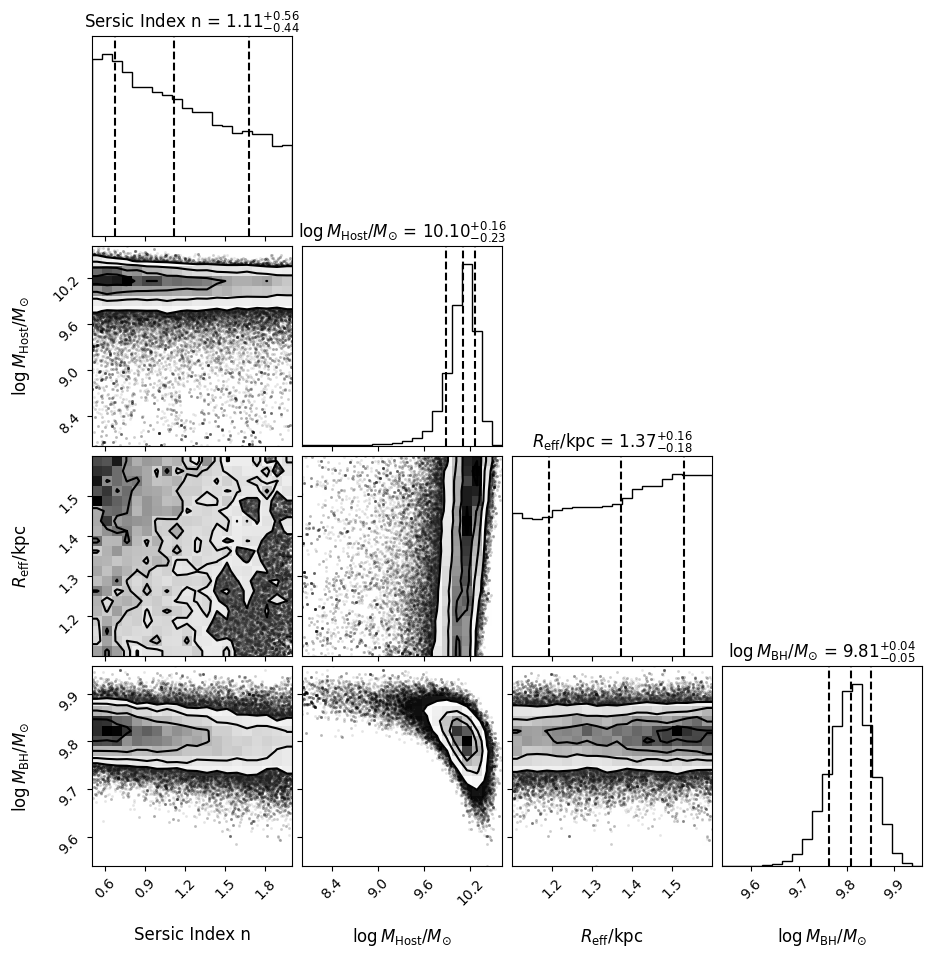

In [11]:
#####
# MCMC
#####

#Initial guesses. Order is n, log Mbulge, re bulge, log Mbh.
params_init = np.array([1.5, 10.5, 1.5, 10.])

#Set the MCMC object, which is just a convenient wrapper for emcee. 
myMCMC = MCMC(params_init, params_min, params_max, modelv, log_prob, data.sigma_obs, data.sigma_obs_err, ifix=ifix)

#Run th MCMC
myMCMC.runMCMC()

#Save the flatchain. 
myMCMC.save_flat_samples("MCMC_flatchain.all_params.constrained_sersic.txt")
#myMCMC.load_flat_samples("MCMC_flatchain.all_params.txt")

#Plot the best-fit model compared to the data. 
myMCMC.plot_bestfit()

#Make the corner plot.
myMCMC.corner_plot()

## Case 3: No SMBH

We also need to compute the fit in the case where the gravity of the SMBH is negligible, and hence only the host component matters. 